In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Reading Dataset
df = pd.read_csv("sales.csv")
df

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,NaN,Mr.,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening
...,...,...,...,...,...,...,...,...,...,...
995,996,3/19/2023,Frankie,Fastfood,50,10,500,NaN,Mrs.,Evening
996,997,9/20/2022,Sandwich,Fastfood,60,7,420,NaN,Mr.,Evening
997,998,1/26/2023,Sandwich,Fastfood,60,13,780,NaN,Mr.,Evening
998,999,8/27/2022,Panipuri,Fastfood,20,5,100,NaN,Mrs.,Afternoon


In [3]:
# Find info of Data Set
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   order_id            1000 non-null   int64
 1   date                1000 non-null   str  
 2   item_name           1000 non-null   str  
 3   item_type           1000 non-null   str  
 4   item_price          1000 non-null   int64
 5   quantity            1000 non-null   int64
 6   transaction_amount  1000 non-null   int64
 7   transaction_type    893 non-null    str  
 8   received_by         1000 non-null   str  
 9   time_of_sale        1000 non-null   str  
dtypes: int64(4), str(6)
memory usage: 78.3 KB


In [4]:
# Find the statistical information for integer columns
df.describe()

,order_id,item_price,quantity,transaction_amount
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,33.315000,8.162000,275.230000
std,288.819436,14.921744,4.413075,204.402979
min,1.000000,20.000000,1.000000,20.000000
25%,250.750000,20.000000,4.000000,120.000000
50%,500.500000,25.000000,8.000000,240.000000
75%,750.250000,50.000000,12.000000,360.000000
max,1000.000000,60.000000,15.000000,900.000000


In [5]:
# Find the statistical information for string columns
df.describe(include = 'str')

,date,item_name,item_type,transaction_type,received_by,time_of_sale
count,1000,1000,1000,893,1000,1000
unique,348,7,2,2,2,5
top,8/31/2022,Cold coffee,Fastfood,Cash,Mr.,Night
freq,8,161,686,476,512,205


In [7]:
# access column data - for single column 
df['item_name']

0             Aalopuri
1              Vadapav
2              Vadapav
3      Sugarcane juice
4      Sugarcane juice
            ...       
995            Frankie
996           Sandwich
997           Sandwich
998           Panipuri
999           Aalopuri
Name: item_name, Length: 1000, dtype: str

In [8]:
# access column data - for multiple column 
df[['item_name', 'item_type', 'transaction_type']]

,item_name,item_type,transaction_type
0,Aalopuri,Fastfood,NaN
1,Vadapav,Fastfood,Cash
2,Vadapav,Fastfood,Cash
3,Sugarcane juice,Beverages,Online
4,Sugarcane juice,Beverages,Online
...,...,...,...
995,Frankie,Fastfood,NaN
996,Sandwich,Fastfood,NaN
997,Sandwich,Fastfood,NaN
998,Panipuri,Fastfood,NaN


In [9]:
# To find the unique value in column
df['item_name'].unique()

<StringArray>
[       'Aalopuri',         'Vadapav', 'Sugarcane juice',        'Panipuri',
         'Frankie',        'Sandwich',     'Cold coffee']
Length: 7, dtype: str

In [10]:
# To find the unique value count
df['item_name'].value_counts()

item_name
Cold coffee        161
Sugarcane juice    153
Panipuri           150
Frankie            139
Aalopuri           134
Vadapav            134
Sandwich           129
Name: count, dtype: int64

In [11]:
# To find the unique value count
df['transaction_type'].value_counts()

transaction_type
Cash      476
Online    417
Name: count, dtype: int64

In [12]:
# To find the unique value count
df['received_by'].value_counts()

received_by
Mr.     512
Mrs.    488
Name: count, dtype: int64

In [13]:
# Handling the missing values
df.isnull()

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,True,False,False
996,False,False,False,False,False,False,False,True,False,False
997,False,False,False,False,False,False,False,True,False,False
998,False,False,False,False,False,False,False,True,False,False


In [14]:
# Handling the missing values
# count the null vales in each column
df.isnull().sum()

order_id                0
date                    0
item_name               0
item_type               0
item_price              0
quantity                0
transaction_amount      0
transaction_type      107
received_by             0
time_of_sale            0
dtype: int64

In [15]:
df['transaction_type'].mode()

0    Cash
Name: transaction_type, dtype: str

In [16]:
# Handling transaction_type column missing value
df['transaction_type'] = df['transaction_type'].fillna('Cash')

In [17]:
df['transaction_type'].isnull().sum()

np.int64(0)

In [18]:
# divide column into categorical & numerical 
categorical_column = ['date', 'item_name', 'item_type', 'transaction_type', 'received_by', 'time_of_sale']
numerical_column = ['order_id', 'item_price', 'quantity', 'transaction_amount']
df.columns

Index(['order_id', 'date', 'item_name', 'item_type', 'item_price', 'quantity',
       'transaction_amount', 'transaction_type', 'received_by',
       'time_of_sale'],
      dtype='str')

In [19]:
df.drop(['order_id', 'date'], axis = 1, inplace = True)
df.head()

,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,Aalopuri,Fastfood,20,13,260,Cash,Mr.,Night
1,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening


In [ ]:
# data Transformation
categorical_column = ['item_name', 'item_type', 'transaction_type', 'received_by', 'time_of_sale']


In [21]:
df['item_name'].unique()
item_name_map = {'Aalopuri' : 1, 'Vadapav' : 2, 'Sugarcane juice' : 3, 'Panipuri' : 4, 'Frankie' : 5, 'Sandwich' : 6, 'Cold coffee' : 7}
df['item_name'] = df['item_name'].replace(item_name_map)
df.head()

,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,Fastfood,20,13,260,Cash,Mr.,Night
1,2,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,2,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,3,Beverages,25,6,150,Online,Mr.,Night
4,3,Beverages,25,8,200,Online,Mr.,Evening


In [22]:
df['item_name'].unique()

array([1, 2, 3, 4, 5, 6, 7], dtype=object)

In [25]:
item_type_map = {'Fastfood' : 0, 'Beverages' : 1}
df['item_type'] = df['item_type'].replace(item_type_map)
df.head()

,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,0,20,13,260,Cash,Mr.,Night
1,2,0,20,15,300,Cash,Mr.,Afternoon
2,2,0,20,1,20,Cash,Mr.,Afternoon
3,3,1,25,6,150,Online,Mr.,Night
4,3,1,25,8,200,Online,Mr.,Evening


In [27]:
transaction_type_map = {'Online' : 0, 'Cash' : 1}
received_by_map = {'Mrs.' : 0, 'Mr.' : 1}
time_of_sale_map = {'Night' : 4, 'Afternoon' : 2, 'Evening' : 3, 'Morning' : 1, 'Midnight' : 5}
df['transaction_type'] = df['transaction_type'].replace(transaction_type_map)
df['received_by'] = df['received_by'].replace(received_by_map)
df['time_of_sale'] = df['time_of_sale'].replace(time_of_sale_map)
df.head()

,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,0,20,13,260,1,1,4
1,2,0,20,15,300,1,1,2
2,2,0,20,1,20,1,1,2
3,3,1,25,6,150,0,1,4
4,3,1,25,8,200,0,1,3


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   item_name           1000 non-null   object
 1   item_type           1000 non-null   object
 2   item_price          1000 non-null   int64 
 3   quantity            1000 non-null   int64 
 4   transaction_amount  1000 non-null   int64 
 5   transaction_type    1000 non-null   object
 6   received_by         1000 non-null   object
 7   time_of_sale        1000 non-null   object
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [31]:
categorical_column = ['item_name', 'item_type', 'transaction_type', 'received_by', 'time_of_sale']
for col in categorical_column:
    df[col] = df[col].astype('int32')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   item_name           1000 non-null   int32
 1   item_type           1000 non-null   int32
 2   item_price          1000 non-null   int64
 3   quantity            1000 non-null   int64
 4   transaction_amount  1000 non-null   int64
 5   transaction_type    1000 non-null   int32
 6   received_by         1000 non-null   int32
 7   time_of_sale        1000 non-null   int32
dtypes: int32(5), int64(3)
memory usage: 43.1 KB


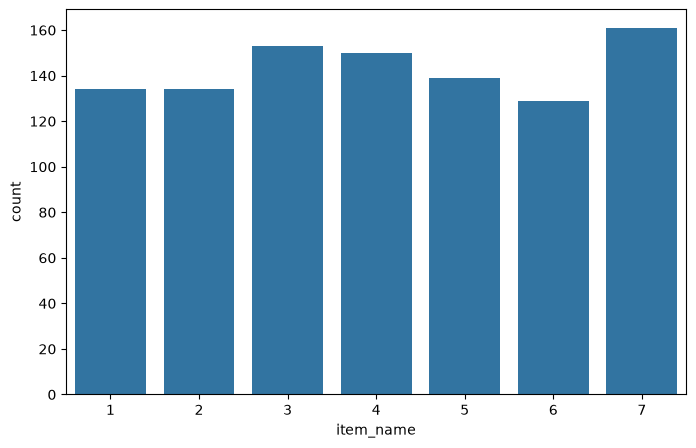

In [33]:
# Data Visualization
# count plot
plt.figure(figsize = (8,5))
sns.countplot(data = df, x = 'item_name')
plt.show()

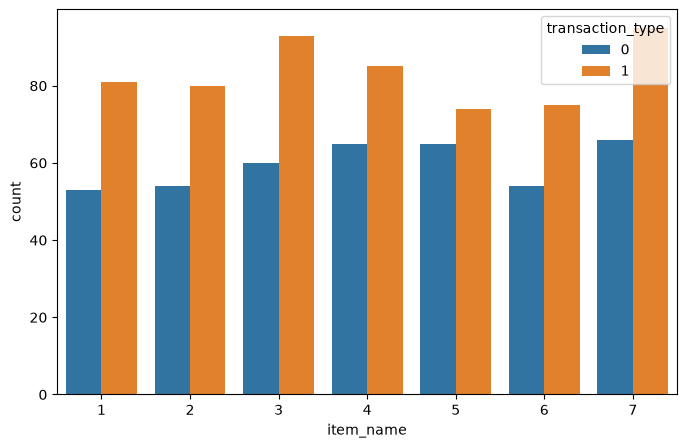

In [34]:
# Data Visualization
# count plot
plt.figure(figsize = (8,5))
sns.countplot(data = df, x = 'item_name', hue = 'transaction_type')
plt.show()

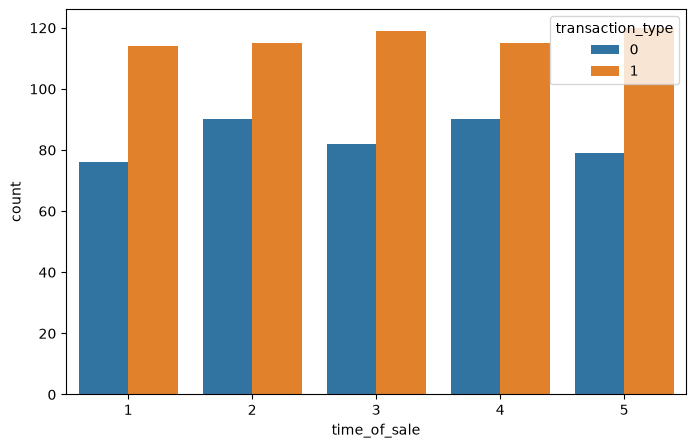

In [35]:
# Data Visualization
# count plot
plt.figure(figsize = (8,5))
sns.countplot(data = df, x = 'time_of_sale', hue = 'transaction_type')
plt.show()

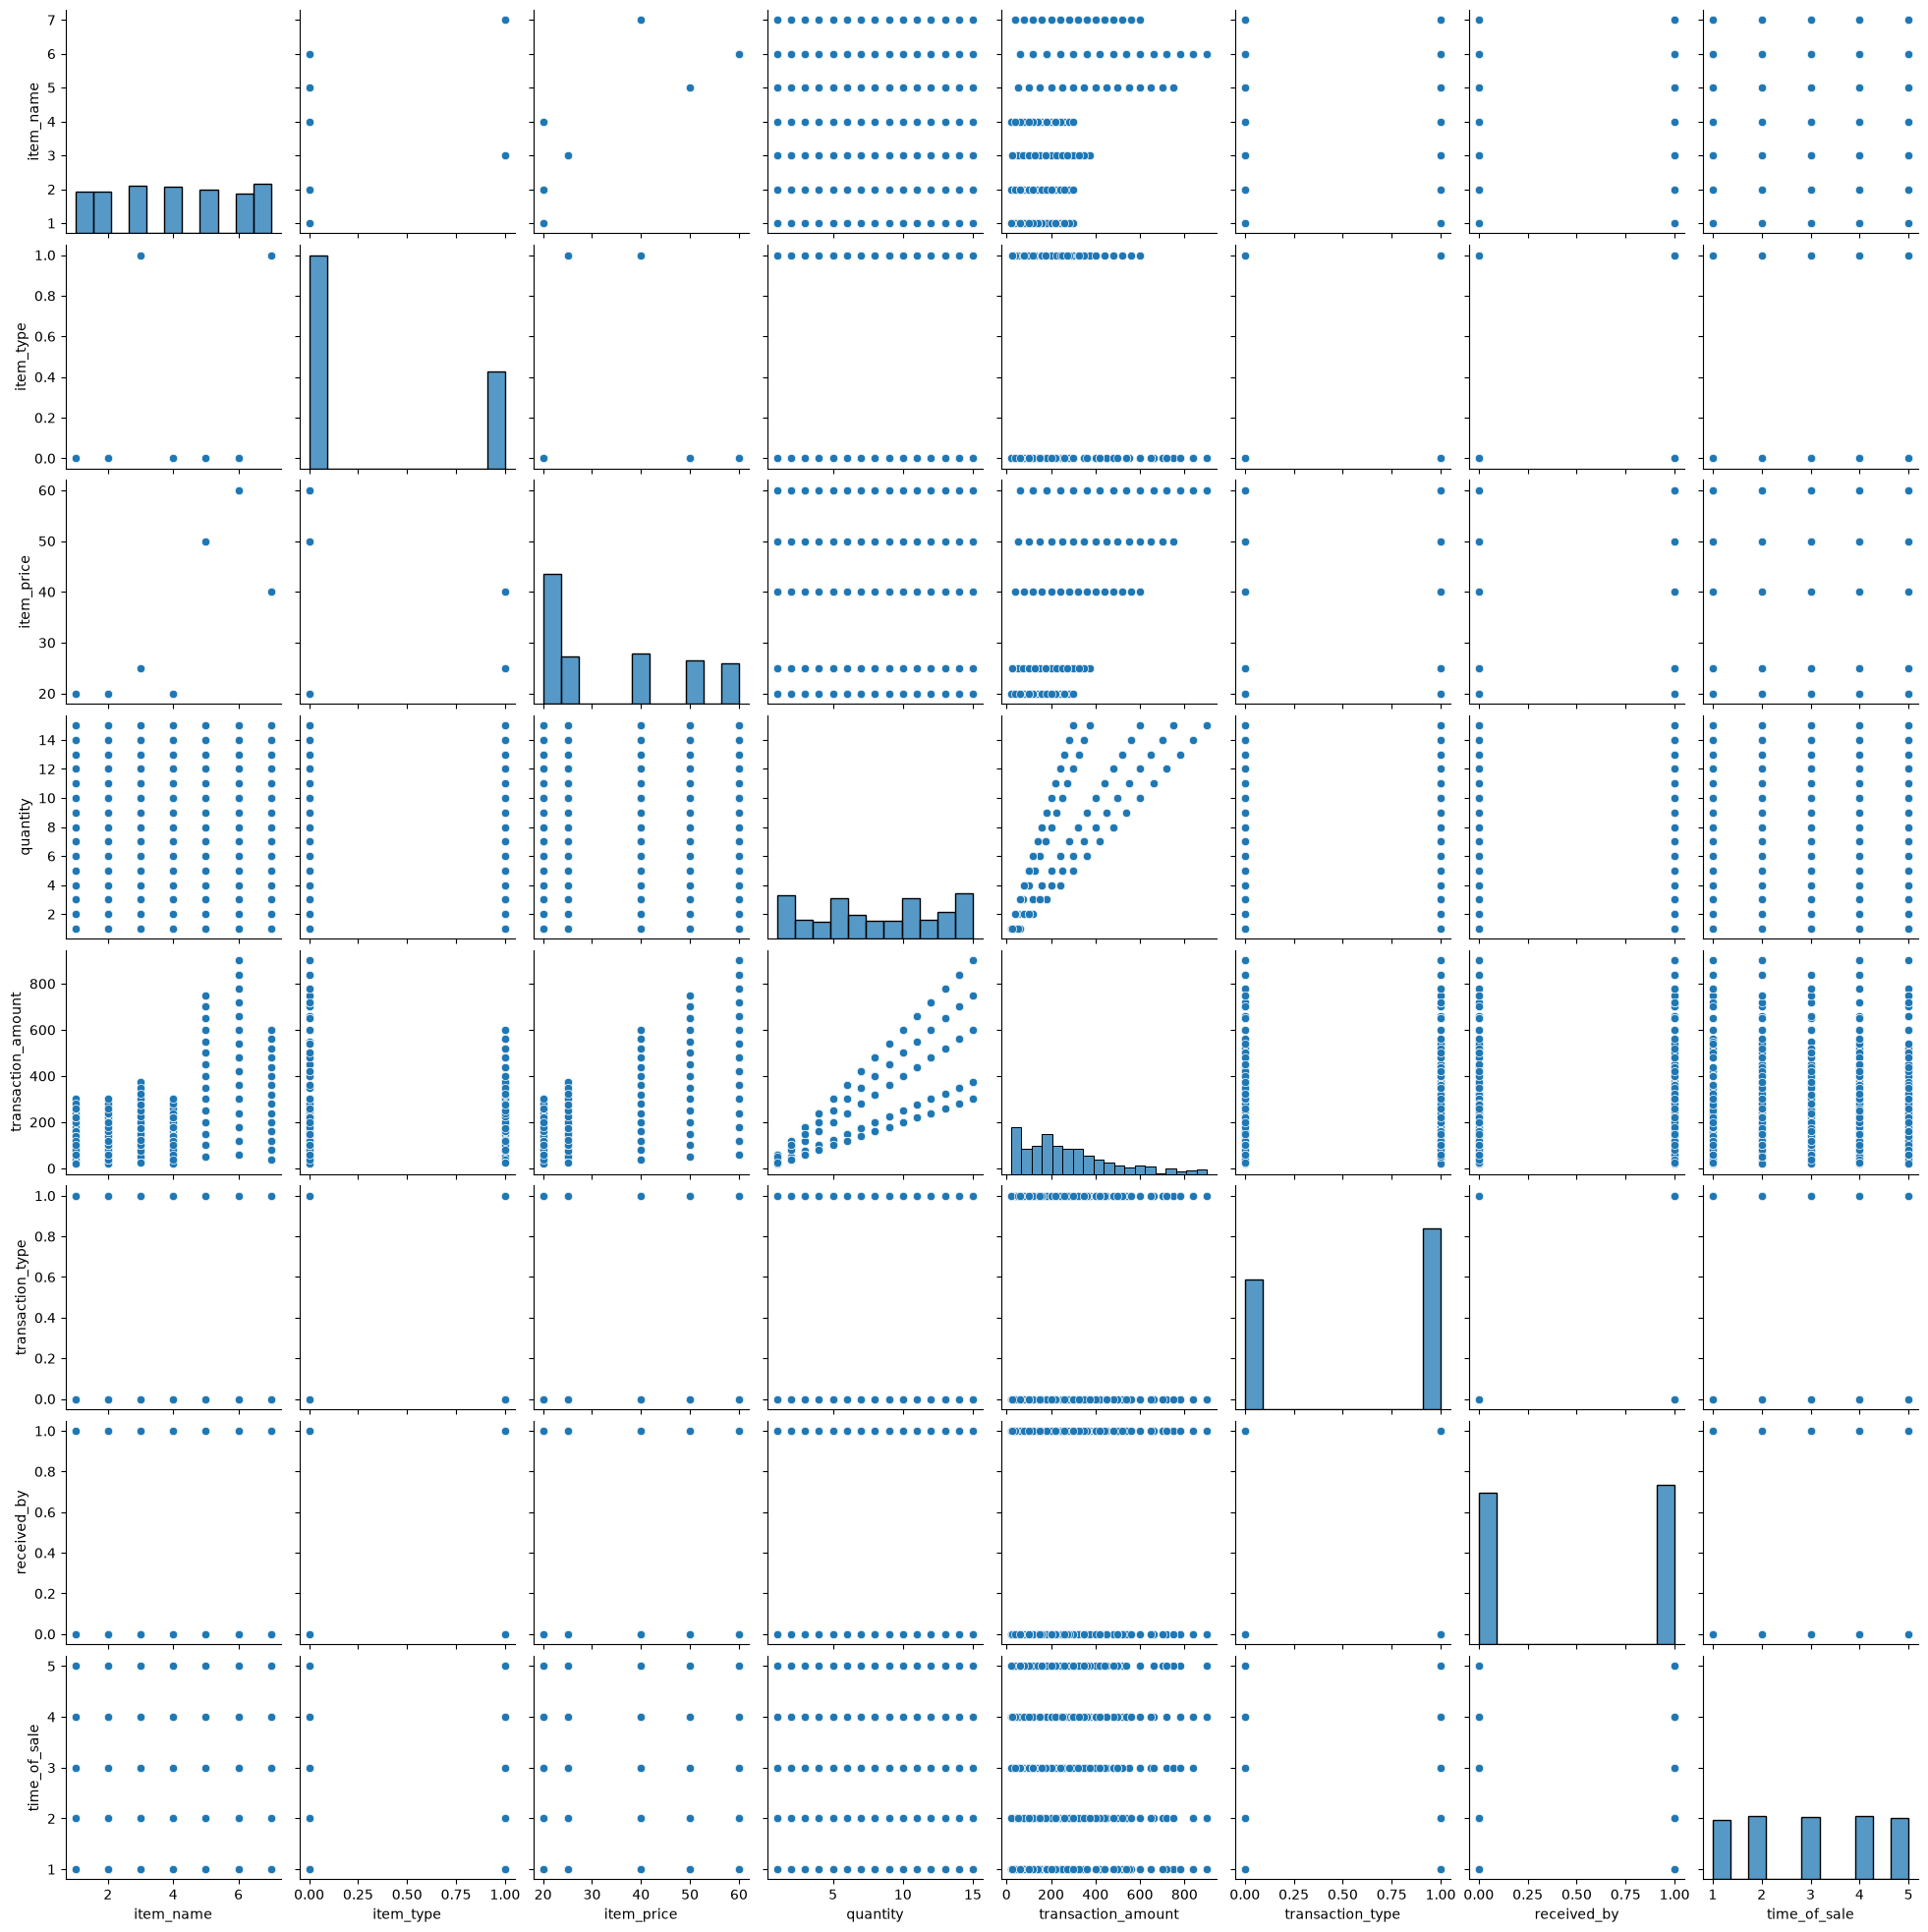

In [36]:
sns.pairplot(data = df)

 - sns.scatterplot
 - sns.kdeplot
 - sns.barplot
 - sns.boxplot
 - sns.lineplot
 - sns.pairplot

In [37]:
df.to_csv('clean_sales.csv', index = False)

<Axes: >

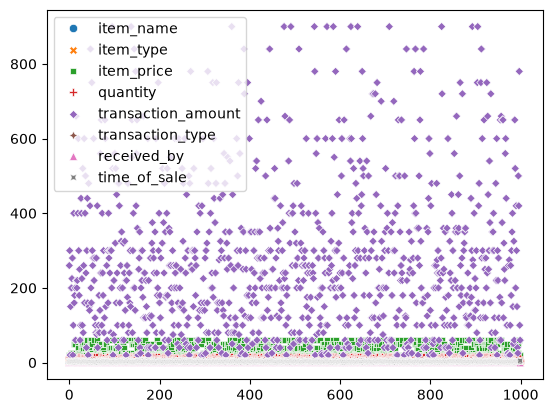

In [38]:
sns.scatterplot(data = df)

<Axes: ylabel='Density'>

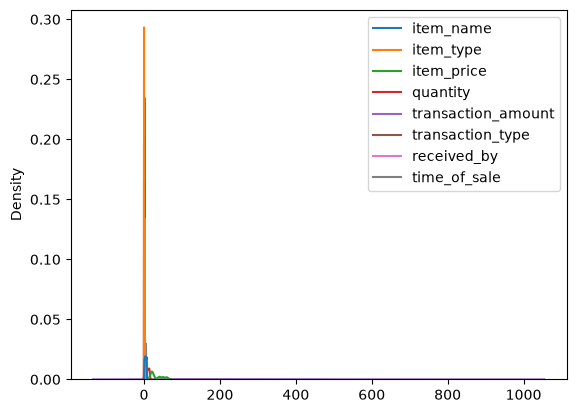

In [39]:
sns.kdeplot(data = df)

<Axes: >

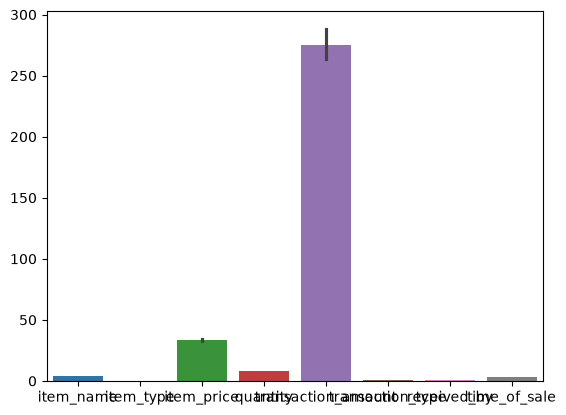

In [40]:
sns.barplot(data = df)

<Axes: >

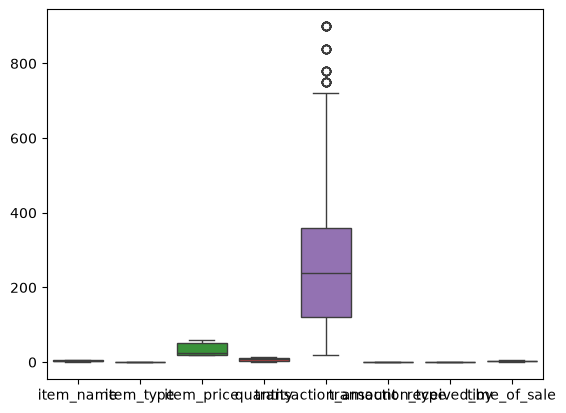

In [41]:
sns.boxplot(data = df)

<Axes: >

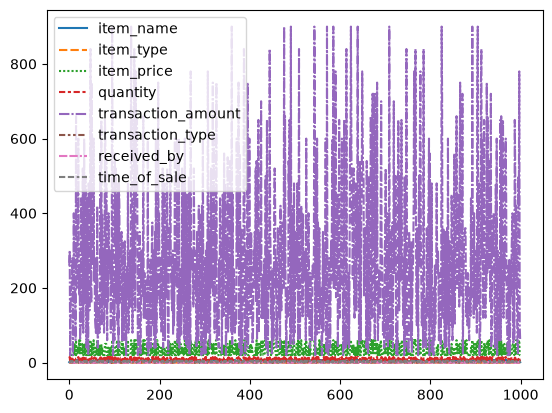

In [42]:
sns.lineplot(data = df)